# Proyecto Final Integrador
## Priorización de contactos en campañas telefónicas: predicción de suscripción a plazo fijo

**Diplomado en Ciencia de Datos y Análisis Avanzado - UTN.BA - Unidad 9**

Este notebook reproduce **todos** los números del informe final siguiendo CRISP-DM:

1. Comprensión del negocio: KPI y métricas.
2. Comprensión de los datos: carga validada y EDA de calidad.
3. Preparación: control de fuga, limpieza e ingeniería de variables.
4. Modelado: baselines, 3 algoritmos y selección por validación cruzada.
5. Evaluación: holdout estable, holdout temporal y lift por deciles.
6. Interpretación: SHAP global agrupado por variable original y SHAP local.
7. Profundización: segmentación, ablaciones de hipótesis y auditoría por grupos.
8. Traducción a negocio: escenario económico.

Todas las salidas se guardan en `results/`. Semilla fija: `random_state=42`.

In [1]:
# Instala dependencias solo si faltan (útil en Google Colab)
import importlib.util, subprocess, sys
for pkg in ['xgboost', 'shap']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
from pathlib import Path
import io, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             accuracy_score, precision_recall_curve, make_scorer)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

RANDOM_STATE = 42
K = 0.30                      # capacidad operativa: 30 % de la cartera
DATA_URL = 'https://archive.ics.uci.edu/static/public/222/bank%2Bmarketing.zip'
DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok=True)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('pandas', pd.__version__, '| shap', shap.__version__)

pandas 3.0.5 | shap 0.52.0


## 1. Comprensión del negocio: KPI y métricas

El call center puede contactar aproximadamente al **30 %** de la cartera. El producto analítico es un **ranking**.

- **Recall @ top 30 %** (KPI de negocio): fracción de todas las suscripciones reales que queda dentro del 30 % con mayor score.
- **PR-AUC** (métrica estadística principal): calidad del ranking con clase positiva minoritaria.
- **Precision @ 30 %, Lift @ 30 %, F1 y accuracy de la regla "contactar el top 30 %"**: complementarias.
- **ROC-AUC**: comparabilidad técnica, no gobierna la decisión.

Meta fijada antes de entrenar: Recall @ 30 % >= 70 % (umbral mínimo 60 %).

In [3]:
def top_k_mask(y_score, k=K):
    # Marca como 'contactar' al k % con mayor score (desempate estable)
    y_score = np.asarray(y_score)
    n = max(1, int(np.ceil(len(y_score) * k)))
    mask = np.zeros(len(y_score), dtype=bool)
    mask[np.argsort(-y_score, kind='mergesort')[:n]] = True
    return mask

def recall_at_k(y_true, y_score, k=K):
    y_true = np.asarray(y_true); pos = y_true.sum()
    return float(y_true[top_k_mask(y_score, k)].sum() / pos) if pos else np.nan

def metrics(y_true, score, k=K):
    y_true = np.asarray(y_true); m = top_k_mask(score, k)
    prec = y_true[m].mean()
    return {'PR_AUC': average_precision_score(y_true, score),
            'ROC_AUC': roc_auc_score(y_true, score),
            'Recall@30': recall_at_k(y_true, score, k),
            'Precision@30': prec,
            'Lift@30': prec / y_true.mean(),
            'F1@30': f1_score(y_true, m.astype(int)),
            'Accuracy@30': accuracy_score(y_true, m.astype(int))}

recall30_scorer = make_scorer(recall_at_k, response_method='predict_proba')

## 2. Comprensión de los datos

Se usa **exclusivamente** `bank-additional-full.csv` (UCI Bank Marketing, Moro, Rita y Cortez, 2014, CC BY 4.0, DOI 10.24432/C5K306).

El zip oficial de UCI contiene **zips anidados** (`bank.zip` y `bank-additional.zip`). La carga los recorre y valida el esquema para no mezclar esta variante con `bank-full.csv`.

In [4]:
def find_member(zf, suffix):
    # Busca el archivo dentro del zip, recorriendo zips anidados
    for name in zf.namelist():
        if name.endswith(suffix) and not name.startswith('__MACOSX'):
            return zf.read(name)
    for name in zf.namelist():
        if name.endswith('.zip'):
            found = find_member(zipfile.ZipFile(io.BytesIO(zf.read(name))), suffix)
            if found is not None:
                return found
    return None

csv_path = DATA_DIR / 'bank-additional-full.csv'
if not csv_path.exists():
    raw = urllib.request.urlopen(DATA_URL, timeout=120).read()
    content = find_member(zipfile.ZipFile(io.BytesIO(raw)), 'bank-additional-full.csv')
    assert content is not None, 'No se encontró bank-additional-full.csv dentro del zip de UCI'
    csv_path.write_bytes(content)

df_raw = pd.read_csv(csv_path, sep=';')
expected = {'age','job','marital','education','default','housing','loan','contact','month',
            'day_of_week','duration','campaign','pdays','previous','poutcome','emp.var.rate',
            'cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y'}
assert set(df_raw.columns) == expected, 'El archivo no corresponde a bank-additional-full.csv'
print('Registros:', df_raw.shape[0], '| Variables de entrada:', df_raw.shape[1] - 1)
print('Prevalencia de suscripción:', round((df_raw.y == 'yes').mean(), 4))

Registros: 41188 | Variables de entrada: 20
Prevalencia de suscripción: 0.1127


### 2.1 Calidad de datos: nulos, categorías `unknown`, duplicados, centinelas y outliers

In [5]:
cat_raw = df_raw.select_dtypes(exclude='number').columns.drop('y')
quality = pd.DataFrame({
    'nulos': df_raw.isna().sum(),
    'unknown': [int((df_raw[c] == 'unknown').sum()) if c in cat_raw else 0 for c in df_raw.columns],
})
quality['unknown_%'] = quality['unknown'] / len(df_raw) * 100
quality = quality[(quality.nulos > 0) | (quality.unknown > 0)].sort_values('unknown', ascending=False)
quality.to_csv(RESULTS / 'eda_calidad.csv')
print('Nulos explícitos totales:', int(df_raw.isna().sum().sum()))
print('Duplicados exactos:', int(df_raw.duplicated().sum()))
print('pdays = 999 (nunca contactado):', f"{(df_raw.pdays == 999).mean():.1%}")
print('default = yes:', int((df_raw.default == 'yes').sum()))
quality

Nulos explícitos totales: 0
Duplicados exactos: 12
pdays = 999 (nunca contactado): 96.3%
default = yes: 3


,nulos,unknown,unknown_%
default,0,8597,20.8726
education,0,1731,4.2027
housing,0,990,2.4036
loan,0,990,2.4036
job,0,330,0.8012
marital,0,80,0.1942


In [6]:
num_desc = df_raw[['age', 'campaign', 'previous', 'duration']].describe(percentiles=[.5, .95, .99]).T
print('Casos con campaign > 10:', int((df_raw.campaign > 10).sum()),
      f"({(df_raw.campaign > 10).mean():.1%})")
num_desc

Casos con campaign > 10: 869 (2.1%)


,count,mean,std,min,50%,95%,99%,max
age,"41,188.0000",40.0241,10.4212,17.0000,38.0000,58.0000,71.0000,98.0000
campaign,"41,188.0000",2.5676,2.7700,1.0000,2.0000,7.0000,14.0000,56.0000
previous,"41,188.0000",0.1730,0.4949,0.0000,0.0000,1.0000,2.0000,7.0000
duration,"41,188.0000",258.2850,259.2792,0.0000,180.0000,752.6500,"1,271.1300","4,918.0000"


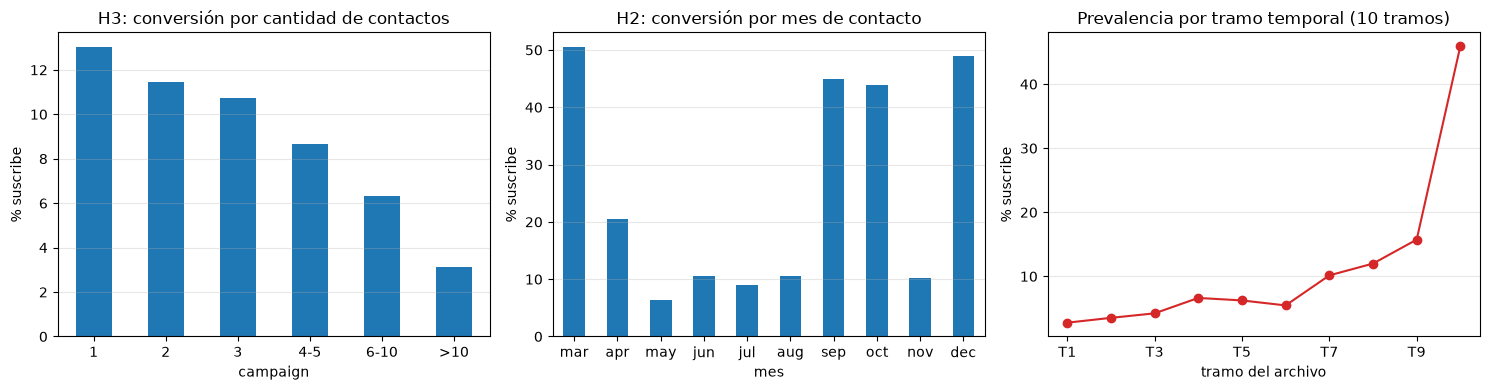

             clientes  tasa_suscripcion
poutcome                               
failure          4252            0.1423
nonexistent     35563            0.0883
success          1373            0.6511


In [7]:
d = df_raw.assign(target=(df_raw.y == 'yes').astype(int))
bins = [0, 1, 2, 3, 5, 10, 100]
labels = ['1', '2', '3', '4-5', '6-10', '>10']
h3 = d.groupby(pd.cut(d.campaign, bins=bins, labels=labels), observed=True).target.agg(['size', 'mean'])
h3.columns = ['clientes', 'tasa_suscripcion']
h1 = d.groupby('poutcome').target.agg(['size', 'mean']).rename(columns={'size': 'clientes', 'mean': 'tasa_suscripcion'})
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
h2 = d.groupby('month').target.agg(['size', 'mean']).reindex(month_order)
h2.columns = ['clientes', 'tasa_suscripcion']
# Prevalencia por tramo del archivo (está ordenado temporalmente)
tramo = d.groupby(pd.qcut(np.arange(len(d)), 10, labels=[f'T{i}' for i in range(1, 11)])).target.mean()

h3.to_csv(RESULTS / 'eda_h3_campaign.csv'); h1.to_csv(RESULTS / 'eda_h1_poutcome.csv')
h2.to_csv(RESULTS / 'eda_h2_mes.csv'); tramo.to_csv(RESULTS / 'eda_prevalencia_por_tramo.csv')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
(h3.tasa_suscripcion * 100).plot.bar(ax=ax[0], color='#1f77b4')
ax[0].set_title('H3: conversión por cantidad de contactos'); ax[0].set_xlabel('campaign'); ax[0].set_ylabel('% suscribe')
(h2.tasa_suscripcion * 100).plot.bar(ax=ax[1], color='#1f77b4')
ax[1].set_title('H2: conversión por mes de contacto'); ax[1].set_xlabel('mes'); ax[1].set_ylabel('% suscribe')
(tramo * 100).plot(ax=ax[2], marker='o', color='#d62728')
ax[2].set_title('Prevalencia por tramo temporal (10 tramos)'); ax[2].set_xlabel('tramo del archivo'); ax[2].set_ylabel('% suscribe')
for a in ax: a.grid(axis='y', alpha=.3); a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(RESULTS / 'fig_eda.png', dpi=160, bbox_inches='tight'); plt.show()
print(h1)

## 3. Preparación de los datos

Decisiones (registradas en `data_log.md`):

| Decisión | Motivo |
|---|---|
| Excluir `duration` | Solo se conoce después de la llamada: usarla es fuga de información. |
| Eliminar los 12 duplicados exactos | Se reportó la cantidad antes de eliminar. |
| Conservar `unknown` como categoría | El faltante puede ser informativo. |
| `pdays = 999` → `contactado_antes` + `dias_desde_contacto` | 999 es un centinela, no una cantidad de días. |
| `campaign` sin recorte | Los valores altos son legítimos; se evalúan con modelos robustos. |
| `month` como categoría | El archivo cubre campañas y meses distintos; H2 se interpreta con cautela. |
| Sin ponderación de clases en este experimento | El objetivo principal es ranking. Esta decisión **no** implica que los scores estén calibrados ni que ponderar sea incorrecto. |

Toda transformación aprendida vive dentro de un `Pipeline`. Si un uso futuro necesitara probabilidades absolutas y no solo ranking, habría que evaluar calibración (por ejemplo Brier/curva de calibración) y calibrar si fuera necesario.

In [8]:
df = df_raw.drop_duplicates().reset_index(drop=True)   # conserva el orden temporal
df['contactado_antes'] = (df.pdays != 999).astype(int)
df['dias_desde_contacto'] = np.where(df.pdays == 999, 0, df.pdays)
y = (df.y == 'yes').astype(int)
X = df.drop(columns=['y', 'duration', 'pdays'])

cat_cols = X.select_dtypes(exclude='number').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print('Filas tras limpieza:', len(X), '| prevalencia:', round(y.mean(), 4))
print('Categóricas:', cat_cols)
print('Numéricas:', num_cols)

def make_pre(scale):
    return ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
         ('num', StandardScaler() if scale else 'passthrough', num_cols)],
        verbose_feature_names_out=False)

models = {
    'Logística': Pipeline([('pre', make_pre(True)),
                           ('model', LogisticRegression(max_iter=3000, C=1.0))]),
    'Random Forest': Pipeline([('pre', make_pre(False)),
                               ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                                n_jobs=-1, random_state=RANDOM_STATE))]),
    'XGBoost': Pipeline([('pre', make_pre(False)),
                         ('model', XGBClassifier(n_estimators=400, max_depth=4, learning_rate=.05,
                                                 subsample=.8, colsample_bytree=.8, eval_metric='logloss',
                                                 random_state=RANDOM_STATE, n_jobs=-1))]),
}

Filas tras limpieza: 41176 | prevalencia: 0.1127
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numéricas: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'contactado_antes', 'dias_desde_contacto']


## 4. Modelado: baselines y selección por validación cruzada

- **Holdout estratificado 80/20**: el 20 % de test no se usa para elegir el modelo.
- **Validación cruzada estratificada de 5 folds** sobre el 80 % de desarrollo: identifica modelos estadísticamente competitivos.
- **Validación temporal interna**: entrenar con el primer 60 % del archivo y validar con el tramo 60-80 %. No toca el último 20 %, que queda como test temporal.
- **Regla de selección fijada ex ante:**
  1. Se consideran empatados los modelos cuya PR-AUC media en CV está a menos de un desvío estándar del mejor.
  2. Si la logística está entre los empatados, se elige por parsimonia/interpretabilidad.
  3. Si no, se usa la PR-AUC temporal interna como desempate.
  4. Si el mejor resultado temporal queda prácticamente en el piso de prevalencia, el desempate se declara **débil** y el elegido queda como **candidato provisional**, no como ganador concluyente.

In [9]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'PR_AUC': 'average_precision', 'ROC_AUC': 'roc_auc', 'Recall@30': recall30_scorer}

cv_rows = []
for name, pipe in models.items():
    res = cross_validate(clone(pipe), X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=1)
    row = {'modelo': name}
    for s in scoring:
        row[f'{s}_media'] = res[f'test_{s}'].mean(); row[f'{s}_desvio'] = res[f'test_{s}'].std()
    cv_rows.append(row)
cv_df = pd.DataFrame(cv_rows).set_index('modelo').sort_values('PR_AUC_media', ascending=False)
cv_df.to_csv(RESULTS / 'cv_5folds.csv')

n = len(X); i60, i80 = int(n * .6), int(n * .8)
tv_rows = []
for name, pipe in models.items():
    s_v = clone(pipe).fit(X.iloc[:i60], y.iloc[:i60]).predict_proba(X.iloc[i60:i80])[:, 1]
    tv_rows.append({'modelo': name, **metrics(y.iloc[i60:i80], s_v)})
tv_df = pd.DataFrame(tv_rows).set_index('modelo')
tv_df.to_csv(RESULTS / 'validacion_temporal_interna.csv')

best = cv_df.index[0]
umbral = cv_df.loc[best, 'PR_AUC_media'] - cv_df.loc[best, 'PR_AUC_desvio']
empatados = cv_df.index[cv_df.PR_AUC_media >= umbral].tolist()
if 'Logística' in empatados:
    CHOSEN = 'Logística'
elif len(empatados) == 1:
    CHOSEN = best
else:
    CHOSEN = tv_df.loc[empatados, 'PR_AUC'].idxmax()
print('Empatados en CV:', empatados)
print('Modelo candidato provisional:', CHOSEN)
print('Prevalencia validación temporal interna:', round(y.iloc[i60:i80].mean(), 4))
display(cv_df)
tv_df[['PR_AUC', 'ROC_AUC', 'Recall@30']]

Empatados en CV: ['XGBoost', 'Random Forest']
Modelo candidato provisional: Random Forest
Prevalencia validación temporal interna: 0.1111


,PR_AUC_media,PR_AUC_desvio,ROC_AUC_media,ROC_AUC_desvio,Recall@30_media,Recall@30_desvio
modelo,,,,,,
XGBoost,0.4665,0.0144,0.8002,0.0076,0.7136,0.0113
Random Forest,0.4660,0.0149,0.7950,0.0078,0.7090,0.0102
Logística,0.4506,0.0139,0.7899,0.0072,0.6995,0.0121


,PR_AUC,ROC_AUC,Recall@30
modelo,,,
Logística,0.0974,0.4766,0.1480
Random Forest,0.1132,0.5223,0.3333
XGBoost,0.0956,0.4497,0.2314


## 5. Evaluación en el test estable (una sola vez)

Se comparan los tres modelos contra el **benchmark operativo de ranking aleatorio**.

El clasificador de clase mayoritaria se reporta aparte: sirve para mostrar que predecir siempre “no” logra una accuracy alta por el desbalance, pero como asigna el mismo score a todos **no define un ranking**, por lo que no corresponde calcular Recall/Precision/Lift @ 30 %.

In [10]:
rng = np.random.default_rng(RANDOM_STATE)

# Baseline de clasificación: útil para discutir accuracy, pero no es un ranking.
majority_baseline = pd.Series({
    'PR_AUC': y_test.mean(),
    'ROC_AUC': 0.5,
    'Accuracy_clasificacion_siempre_no': (y_test == 0).mean(),
})
majority_baseline.to_csv(RESULTS / 'baseline_mayoritaria.csv', header=['valor'])
print('Baseline clase mayoritaria (sin métricas @30):')
display(majority_baseline)

# Benchmark operativo de ranking + modelos.
test_rows = [
    {'modelo': 'Baseline: ranking aleatorio', **metrics(y_test, rng.random(len(y_test)))},
]
fitted, test_scores = {}, {}
for name, pipe in models.items():
    fitted[name] = clone(pipe).fit(X_dev, y_dev)
    test_scores[name] = fitted[name].predict_proba(X_test)[:, 1]
    test_rows.append({'modelo': name, **metrics(y_test, test_scores[name])})
test_df = pd.DataFrame(test_rows).set_index('modelo')
test_df.to_csv(RESULTS / 'model_metrics.csv')
test_df

Baseline clase mayoritaria (sin métricas @30):


PR_AUC                              0.1127
ROC_AUC                             0.5000
Accuracy_clasificacion_siempre_no   0.8873
dtype: float64

                             PR_AUC  ROC_AUC  Recall@30  Precision@30  \
modelo                                                                  
Baseline: ranking aleatorio  0.1165   0.5051     0.3039        0.1141   
Logística                    0.4536   0.8005     0.7274        0.2732   
Random Forest                0.4850   0.8032     0.7284        0.2736   
XGBoost                      0.4810   0.8100     0.7371        0.2768   

                             Lift@30  F1@30  Accuracy@30  
modelo                                                      
Baseline: ranking aleatorio   1.0128 0.1659       0.6558  
Logística                     2.4244 0.3972       0.7512  
Random Forest                 2.4280 0.3978       0.7515  
XGBoost                       2.4567 0.4025       0.7534  

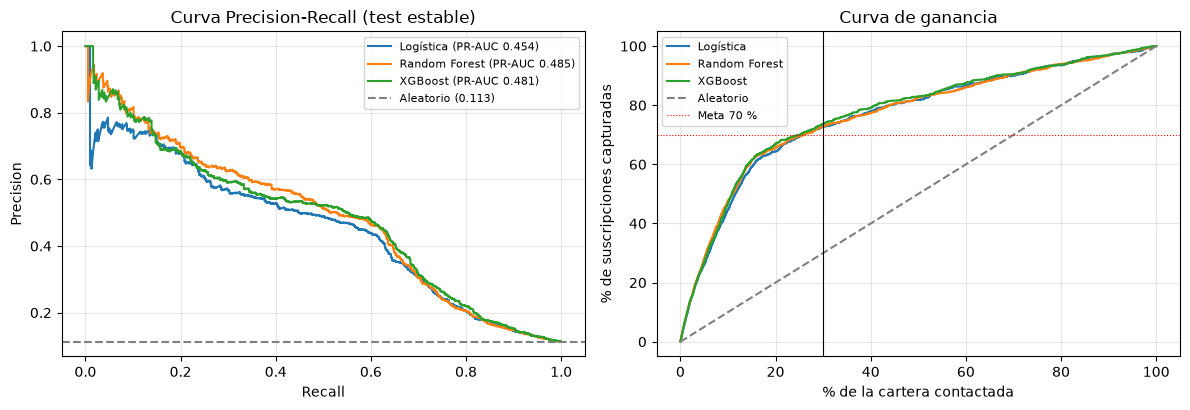

,clientes,suscripciones,tasa,lift,recall_acumulado
decil,,,,,
1,824,444,0.5388,4.7822,0.4784
2,824,164,0.1990,1.7664,0.6552
3,823,68,0.0826,0.7333,0.7284
4,824,42,0.0510,0.4524,0.7737
5,823,48,0.0583,0.5176,0.8254
6,824,33,0.0400,0.3554,0.8610
7,824,40,0.0485,0.4308,0.9041
8,823,33,0.0401,0.3559,0.9397
9,824,26,0.0316,0.2800,0.9677


In [11]:
# Lift por deciles del candidato
s = test_scores[CHOSEN]
dec = pd.DataFrame({'y': y_test.values, 's': s}).sort_values('s', ascending=False).reset_index(drop=True)
dec['decil'] = np.arange(len(dec)) * 10 // len(dec) + 1
lift = dec.groupby('decil').agg(clientes=('y', 'size'), suscripciones=('y', 'sum'), tasa=('y', 'mean'))
lift['lift'] = lift.tasa / y_test.mean()
lift['recall_acumulado'] = lift.suscripciones.cumsum() / y_test.sum()
lift.to_csv(RESULTS / 'lift_deciles.csv')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for name in models:
    p, r, _ = precision_recall_curve(y_test, test_scores[name])
    ax[0].plot(r, p, label=f"{name} (PR-AUC {test_df.loc[name, 'PR_AUC']:.3f})")
ax[0].axhline(y_test.mean(), ls='--', color='grey', label=f'Aleatorio ({y_test.mean():.3f})')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].set_title('Curva Precision-Recall (test estable)')
ax[0].legend(fontsize=8)
for name in models:
    order = np.argsort(-test_scores[name], kind='mergesort')
    gain = np.cumsum(y_test.values[order]) / y_test.sum()
    ax[1].plot(np.arange(1, len(gain) + 1) / len(gain) * 100, gain * 100, label=name)
ax[1].plot([0, 100], [0, 100], ls='--', color='grey', label='Aleatorio')
ax[1].axvline(30, color='black', lw=.8); ax[1].axhline(70, color='red', lw=.8, ls=':', label='Meta 70 %')
ax[1].set_xlabel('% de la cartera contactada'); ax[1].set_ylabel('% de suscripciones capturadas')
ax[1].set_title('Curva de ganancia'); ax[1].legend(fontsize=8)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(RESULTS / 'fig_pr_ganancia.png', dpi=160, bbox_inches='tight'); plt.show()
lift

## 6. Validación temporal

El archivo está ordenado cronológicamente (mayo 2008 - noviembre 2010). Se entrena con el primer 80 % y se evalúa en el último 20 %. **Se conserva aunque el resultado sea peor**: responde si el modelo generaliza hacia el futuro.

Como la prevalencia cambia, el PR-AUC se interpreta junto a su piso (la prevalencia del test): `PR-AUC / prevalencia`.

In [12]:
cut = int(len(X) * .8)
X_tr_t, X_te_t, y_tr_t, y_te_t = X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]
print(f'Prevalencia entrenamiento: {y_tr_t.mean():.1%} | prevalencia test temporal: {y_te_t.mean():.1%}')
temporal_rows = [{'modelo': 'Baseline: ranking aleatorio', **metrics(y_te_t, rng.random(len(y_te_t)))}]
for name, pipe in models.items():
    s_t = clone(pipe).fit(X_tr_t, y_tr_t).predict_proba(X_te_t)[:, 1]
    temporal_rows.append({'modelo': name, **metrics(y_te_t, s_t)})
temporal_df = pd.DataFrame(temporal_rows).set_index('modelo')
temporal_df['PR_AUC/prevalencia'] = temporal_df.PR_AUC / y_te_t.mean()
temporal_df.to_csv(RESULTS / 'temporal_metrics.csv')
temporal_df

Prevalencia entrenamiento: 6.4% | prevalencia test temporal: 30.8%


,PR_AUC,ROC_AUC,Recall@30,Precision@30,Lift@30,F1@30,Accuracy@30,PR_AUC/prevalencia
modelo,,,,,,,,
Baseline: ranking aleatorio,0.3089,0.5019,0.3080,0.3165,1.0266,0.3122,0.5816,1.0020
Logística,0.5271,0.7479,0.5360,0.5508,1.7866,0.5433,0.7222,1.7097
Random Forest,0.5383,0.7431,0.5286,0.5431,1.7617,0.5357,0.7176,1.7461
XGBoost,0.4379,0.6377,0.4360,0.4480,1.4532,0.4419,0.6605,1.4206


## 7. Interpretabilidad con SHAP

Se explica el **modelo candidato provisional** sobre una muestra del **test**. Las columnas one-hot se suman por variable original para presentar conceptos comprensibles para negocio.

- Global: `mean(|SHAP|)` por variable original.
- Local: un cliente real del test; **valor esperado del output del modelo + suma de contribuciones = score del modelo**.
- Para Random Forest, la implementación usada reconstruye el output de `predict_proba`; esto **no implica calibración perfecta**.
- En este proyecto el score se usa para ranking. Para usarlo como probabilidad absoluta habría que evaluar calibración explícitamente.
- SHAP explica cómo razona el modelo; **no demuestra causalidad**.

Escala de SHAP: probabilidad | valor esperado del output del modelo: 0.1126


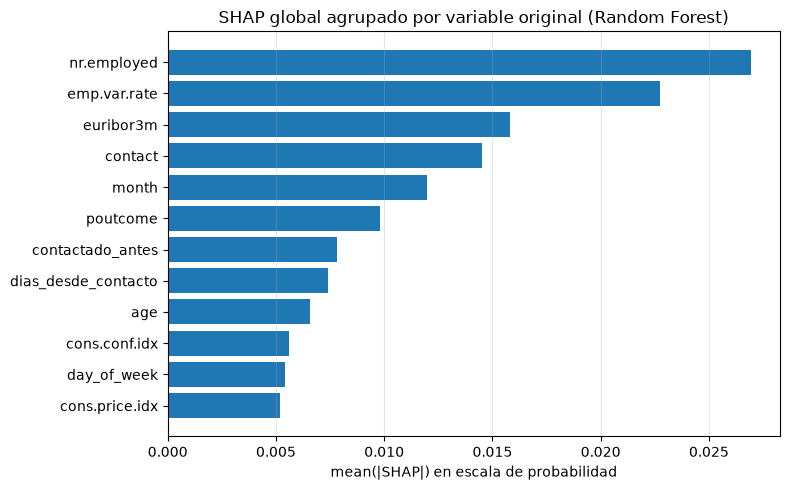

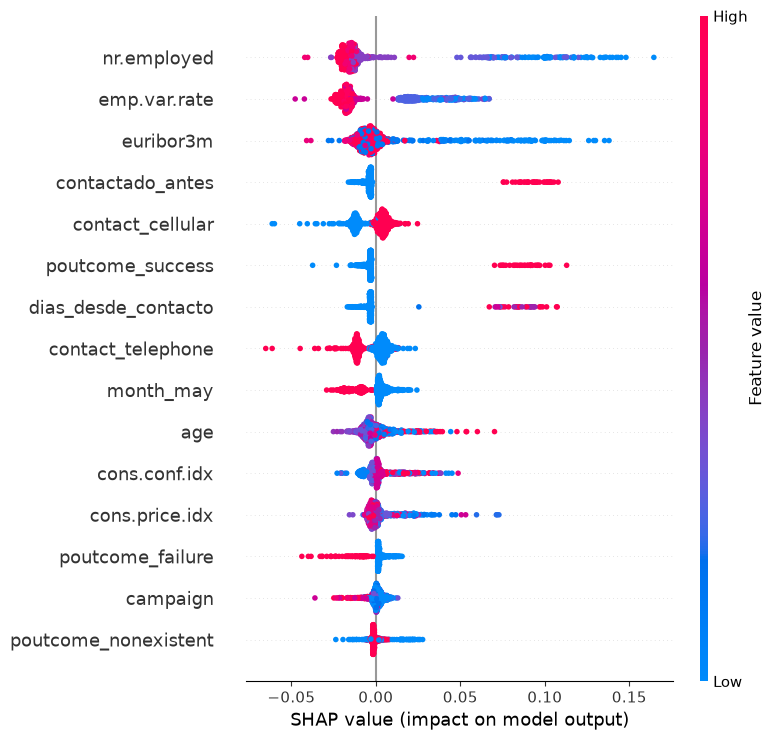

,mean_abs_shap,direccion_media
nr.employed,0.0269,0.0012
emp.var.rate,0.0227,-0.0002
euribor3m,0.0158,0.0073
contact,0.0145,-0.0031
month,0.0120,-0.0012
poutcome,0.0098,0.0005
contactado_antes,0.0078,0.0003
dias_desde_contacto,0.0074,-0.0000
age,0.0066,0.0004
cons.conf.idx,0.0056,0.0018


In [13]:
pipe = fitted[CHOSEN]
pre, model = pipe.named_steps['pre'], pipe.named_steps['model']
feature_names = pre.get_feature_names_out()

def original_var(fname):
    for c in cat_cols:
        if fname.startswith(c + '_'):
            return c
    return fname
groups = np.array([original_var(f) for f in feature_names])

sample_idx = rng.choice(len(X_test), size=min(800, len(X_test)), replace=False)
Xt_sample = pre.transform(X_test.iloc[sample_idx])
if CHOSEN == 'Logística':
    explainer = shap.LinearExplainer(model, pre.transform(X_dev.sample(2000, random_state=RANDOM_STATE)))
    link_note = 'log-odds'
else:
    explainer = shap.TreeExplainer(model)
    link_note = 'probabilidad' if CHOSEN == 'Random Forest' else 'log-odds'

def shap_values(Xt):
    e = explainer(Xt)
    v, b = np.asarray(e.values), np.asarray(e.base_values)
    if v.ndim == 3: v = v[:, :, 1]
    if b.ndim == 2: b = b[:, 1]
    return v, np.ravel(b)

values, base_values = shap_values(Xt_sample)
grouped = pd.DataFrame(values, columns=groups).T.groupby(level=0).sum().T   # suma por variable original
shap_global = grouped.abs().mean().sort_values(ascending=False).rename('mean_abs_shap').to_frame()
shap_global['direccion_media'] = grouped.mean().reindex(shap_global.index)
shap_global.to_csv(RESULTS / 'shap_global.csv')
print('Escala de SHAP:', link_note, '| valor esperado del output del modelo:', round(float(base_values[0]), 4))

fig, ax = plt.subplots(figsize=(8, 5))
top = shap_global.head(12).iloc[::-1]
ax.barh(top.index, top.mean_abs_shap, color='#1f77b4')
ax.set_title(f'SHAP global agrupado por variable original ({CHOSEN})')
ax.set_xlabel(f'mean(|SHAP|) en escala de {link_note}'); ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.savefig(RESULTS / 'fig_shap_global.png', dpi=160, bbox_inches='tight'); plt.show()

shap.summary_plot(values, Xt_sample, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout(); plt.savefig(RESULTS / 'shap_summary_dummies.png', dpi=160, bbox_inches='tight'); plt.show()
shap_global.head(12)

Valor esperado del output: 0.1126 | suma SHAP: +0.0867 | base + suma: 0.1992 | score del modelo: 0.1992


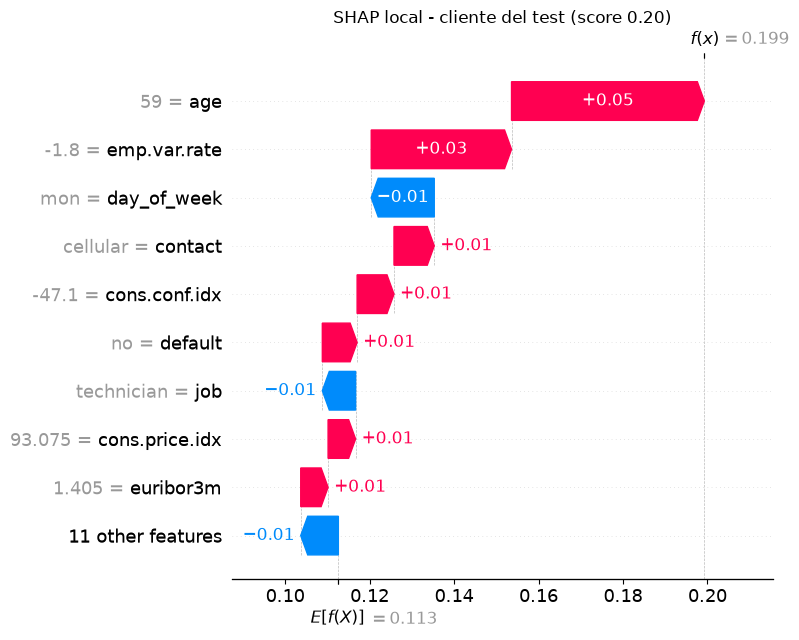

,shap,valor
age,0.0457,59
emp.var.rate,0.0332,-1.8
day_of_week,-0.0149,mon
contact,0.0095,cellular
cons.conf.idx,0.0087,-47.1
default,0.0082,no
job,-0.0079,technician
cons.price.idx,0.0065,93.075
euribor3m,0.0065,1.405
marital,-0.0047,divorced


In [14]:
# Caso local: un suscriptor real dentro del top 30 %, con score cercano a la mediana de ese top
s = test_scores[CHOSEN]
in_top = top_k_mask(s)
cands = np.where(in_top & (y_test.values == 1))[0]
median_top = np.median(s[in_top])
case_pos = int(cands[np.argmin(np.abs(s[cands] - median_top))])
row = X_test.iloc[[case_pos]]
v_case, b_case = shap_values(pre.transform(row))
local = (pd.Series(v_case[0], index=groups).groupby(level=0).sum()
         .rename('shap').to_frame())
local['valor'] = [str(row.iloc[0][c]) for c in local.index]
local = local.reindex(local.shap.abs().sort_values(ascending=False).index)
local.to_csv(RESULTS / 'shap_local_case.csv')

score_model = s[case_pos]
print(f'Valor esperado del output: {b_case[0]:.4f} | suma SHAP: {local.shap.sum():+.4f} | '
      f'base + suma: {b_case[0] + local.shap.sum():.4f} | score del modelo: {score_model:.4f}')

exp = shap.Explanation(values=local.shap.values, base_values=float(b_case[0]),
                       data=local.valor.values, feature_names=local.index.tolist())
shap.plots.waterfall(exp, max_display=10, show=False)
plt.title(f'SHAP local - cliente del test (score {score_model:.2f})')
plt.tight_layout(); plt.savefig(RESULTS / 'fig_shap_local.png', dpi=160, bbox_inches='tight'); plt.show()
local.head(10)

## 8. Profundización

### 8.1 ¿Conviene un modelo por segmento?
Se entrena un modelo del mismo tipo por segmento, se combinan los scores y se evalúa el ranking global sobre el **mismo test**.

In [15]:
def age_band(a):
    return pd.cut(a, bins=[0, 29, 44, 59, 120], labels=['<30', '30-44', '45-59', '60+'])

segmentations = {
    'Por contacto previo': lambda d: d['contactado_antes'].astype(str),
    'Por canal': lambda d: d['contact'].astype(str),
    'Por franja etaria': lambda d: age_band(d['age']).astype(str),
}
seg_rows = [{'estrategia': 'Modelo global', **metrics(y_test, test_scores[CHOSEN])}]
for label, fn in segmentations.items():
    seg_dev, seg_test = fn(X_dev), fn(X_test)
    combined = np.zeros(len(X_test))
    for g in seg_test.unique():
        m_dev, m_test = (seg_dev == g).values, (seg_test == g).values
        combined[m_test] = clone(models[CHOSEN]).fit(X_dev[m_dev], y_dev[m_dev]).predict_proba(X_test[m_test])[:, 1]
    seg_rows.append({'estrategia': label, **metrics(y_test, combined)})
seg_df = pd.DataFrame(seg_rows).set_index('estrategia')[['PR_AUC', 'ROC_AUC', 'Recall@30']]
seg_df.to_csv(RESULTS / 'segmentacion.csv')
seg_df

,PR_AUC,ROC_AUC,Recall@30
estrategia,,,
Modelo global,0.4850,0.8032,0.7284
Por contacto previo,0.4861,0.8051,0.7241
Por canal,0.4837,0.8036,0.7274
Por franja etaria,0.4745,0.8016,0.7274


### 8.2 Ablaciones de hipótesis
Se reentrena el candidato **sin** un bloque de variables y se mide la caída sobre el mismo test.

- **H1** historial previo: `dias_desde_contacto`, `contactado_antes`, `previous`, `poutcome`.
- **H2** calendario: `month`, `day_of_week`.
- **Contexto macro** (riesgo de drift): `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`.

H3 (rendimientos decrecientes de `campaign`) se evalúa descriptivamente en el EDA.

In [16]:
blocks = {
    'H1 - sin historial previo': ['dias_desde_contacto', 'contactado_antes', 'previous', 'poutcome'],
    'H2 - sin calendario': ['month', 'day_of_week'],
    'Sin contexto macroeconómico': ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
}
base_m = metrics(y_test, test_scores[CHOSEN])
abl_rows = [{'escenario': 'Modelo completo', 'PR_AUC': base_m['PR_AUC'], 'Recall@30': base_m['Recall@30'],
             'delta_PR_AUC': 0.0, 'delta_Recall@30': 0.0}]
for label, cols in blocks.items():
    keep_cat = [c for c in cat_cols if c not in cols]; keep_num = [c for c in num_cols if c not in cols]
    pre_a = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), keep_cat),
         ('num', StandardScaler() if CHOSEN == 'Logística' else 'passthrough', keep_num)])
    pipe_a = Pipeline([('pre', pre_a), ('model', clone(models[CHOSEN].named_steps['model']))])
    s_a = pipe_a.fit(X_dev, y_dev).predict_proba(X_test)[:, 1]
    m_a = metrics(y_test, s_a)
    abl_rows.append({'escenario': label, 'PR_AUC': m_a['PR_AUC'], 'Recall@30': m_a['Recall@30'],
                     'delta_PR_AUC': m_a['PR_AUC'] - base_m['PR_AUC'],
                     'delta_Recall@30': m_a['Recall@30'] - base_m['Recall@30']})
abl_df = pd.DataFrame(abl_rows).set_index('escenario')
abl_df.to_csv(RESULTS / 'ablaciones.csv')
abl_df

,PR_AUC,Recall@30,delta_PR_AUC,delta_Recall@30
escenario,,,,
Modelo completo,0.4850,0.7284,0.0000,0.0000
H1 - sin historial previo,0.4360,0.7188,-0.0490,-0.0097
H2 - sin calendario,0.4760,0.7155,-0.0090,-0.0129
Sin contexto macroeconómico,0.4263,0.6864,-0.0587,-0.0420


### 8.3 Auditoría por grupos (ética)
Para cada grupo se reporta participación en la cartera, participación dentro del top 30 % y recall. Diferencias grandes muestran que el ranking concentra o excluye grupos y requieren revisión.

**Una diferencia de prevalencia observada entre grupos no demuestra ausencia de sesgo ni justifica automáticamente el trato diferencial.** La auditoría debe complementarse con criterios normativos, revisión de negocio y, cuando corresponda, comparación con modelos sin atributos sensibles.

In [17]:
def group_audit(col_values, name):
    t = pd.DataFrame({'grupo': np.asarray(col_values), 'y': y_test.values, 'top': top_k_mask(test_scores[CHOSEN])})
    out = t.groupby('grupo', observed=True).agg(clientes=('y', 'size'), prevalencia=('y', 'mean'),
                                                seleccionados=('top', 'mean'))
    out['share_cartera'] = out.clientes / len(t)
    out['share_top30'] = t[t.top].groupby('grupo', observed=True).size() / t.top.sum()
    out['recall_grupo'] = t[t.y == 1].groupby('grupo', observed=True).top.mean()
    out.insert(0, 'atributo', name)
    return out

audit = pd.concat([group_audit(age_band(X_test.age).astype(str), 'edad'),
                   group_audit(X_test.marital, 'estado civil')])
audit.to_csv(RESULTS / 'auditoria_grupos.csv')
audit

,atributo,clientes,prevalencia,seleccionados,share_cartera,share_top30,recall_grupo
grupo,,,,,,,
30-44,edad,4591,0.1046,0.2555,0.5574,0.4747,0.6562
45-59,edad,2353,0.0816,0.2461,0.2857,0.2343,0.6771
60+,edad,215,0.4093,0.8884,0.0261,0.0773,0.9886
<30,edad,1077,0.1560,0.4903,0.1308,0.2137,0.8571
divorced,estado civil,911,0.1142,0.2536,0.1106,0.0935,0.5962
married,estado civil,5006,0.0985,0.2667,0.6078,0.5403,0.6998
single,estado civil,2307,0.1430,0.3906,0.2801,0.3646,0.8152
unknown,estado civil,12,0.0833,0.3333,0.0015,0.0016,0.0000


## 9. Traducción a negocio: escenario económico (paramétrico)

Supuestos (no son costos reales de un banco): campaña de 41.000 clientes, USD 1,20 por llamada, CAPEX inicial USD 9.400 y OPEX anual USD 3.360.

Lógica: sin ranking, capturar una fracción *R* de las suscripciones exige llamar aproximadamente a *R* de la cartera. Con el modelo se capturan *R* llamando al 30 %. Llamadas evitadas = (R − 0,30) × base.

In [18]:
BASE, COSTO, CAPEX, OPEX = 41_000, 1.20, 9_400, 3_360
def escenario(nombre, R):
    evitadas = max(0.0, R - K) * BASE
    ahorro = evitadas * COSTO
    return {'escenario': nombre, 'Recall@30': R, 'llamadas_evitadas': round(evitadas),
            'ahorro_campania_USD': round(ahorro), 'beneficio_neto_anio1_USD': round(ahorro - CAPEX - OPEX)}

econ = pd.DataFrame([
    escenario('Meta de diseño (70 %)', 0.70),
    escenario(f'Test estable ({CHOSEN})', metrics(y_test, test_scores[CHOSEN])['Recall@30']),
    escenario(f'Test temporal ({CHOSEN})', temporal_df.loc[CHOSEN, 'Recall@30']),
]).set_index('escenario')
econ.to_csv(RESULTS / 'escenario_economico.csv')
econ

,Recall@30,llamadas_evitadas,ahorro_campania_USD,beneficio_neto_anio1_USD
escenario,,,,
Meta de diseño (70 %),0.7000,16400,19680,6920
Test estable (Random Forest),0.7284,17566,21080,8320
Test temporal (Random Forest),0.5286,9371,11245,-1515


## 10. Resumen de resultados

In [19]:
resumen = {
    'modelo_candidato_provisional': CHOSEN,
    'cv_PR_AUC': round(cv_df.loc[CHOSEN, 'PR_AUC_media'], 4),
    'test_PR_AUC': round(test_df.loc[CHOSEN, 'PR_AUC'], 4),
    'test_Recall@30': round(test_df.loc[CHOSEN, 'Recall@30'], 4),
    'temporal_PR_AUC': round(temporal_df.loc[CHOSEN, 'PR_AUC'], 4),
    'temporal_Recall@30': round(temporal_df.loc[CHOSEN, 'Recall@30'], 4),
    'prevalencia_train_temporal': round(y_tr_t.mean(), 4),
    'prevalencia_test_temporal': round(y_te_t.mean(), 4),
}
pd.Series(resumen).to_csv(RESULTS / 'resumen.csv', header=['valor'])
pd.Series(resumen)

modelo_candidato_provisional  Random Forest
cv_PR_AUC                            0.4660
test_PR_AUC                          0.4850
test_Recall@30                       0.7284
temporal_PR_AUC                      0.5383
temporal_Recall@30                   0.5286
prevalencia_train_temporal           0.0638
prevalencia_test_temporal            0.3083
dtype: object

**Conclusión metodológica:** existe señal útil para priorizar contactos en distribución estable, pero la validación temporal muestra un cambio de régimen. Random Forest es el **candidato provisional** definido por la regla ex ante; la validación temporal interna no demuestra una superioridad fuerte. SHAP y las ablaciones muestran alta dependencia del bloque macroeconómico, pero no permiten atribuir causalmente todo el drift a esas variables. La recomendación proporcional a la evidencia es **reentrenar con datos actuales y ejecutar un piloto A/B** con el mismo presupuesto de llamadas antes de cualquier despliegue.